In [2]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

(11610, 8) (5160, 8) (3870, 8)


In [4]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [6]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			# for group in optimizer.param_groups:
			# 	for p in group['params']:
			# 		if p.grad is not None:
			# 			print(f'\t{p.grad.max()}') 
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# if epoch>=2:
		# 	break
	return history

def plot_history(history, n_epochs):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

Epoch: 1/20, Loss: 0.755, Train Metric: 0.622, Valid Metric: 0.517
Epoch: 2/20, Loss: 0.455, Train Metric: 0.486, Valid Metric: 0.476
Epoch: 3/20, Loss: 0.411, Train Metric: 0.458, Valid Metric: 0.461
Epoch: 4/20, Loss: 0.393, Train Metric: 0.446, Valid Metric: 0.463
Epoch: 5/20, Loss: 0.382, Train Metric: 0.438, Valid Metric: 0.453
Epoch: 6/20, Loss: 0.377, Train Metric: 0.435, Valid Metric: 0.446
Epoch: 7/20, Loss: 0.368, Train Metric: 0.429, Valid Metric: 0.434
Epoch: 8/20, Loss: 0.359, Train Metric: 0.424, Valid Metric: 0.429
Epoch: 9/20, Loss: 0.354, Train Metric: 0.42, Valid Metric: 0.426
Epoch: 10/20, Loss: 0.348, Train Metric: 0.416, Valid Metric: 0.429
Epoch: 11/20, Loss: 0.346, Train Metric: 0.414, Valid Metric: 0.424
Epoch: 12/20, Loss: 0.342, Train Metric: 0.412, Valid Metric: 0.414
Epoch: 13/20, Loss: 0.338, Train Metric: 0.408, Valid Metric: 0.419
Epoch: 14/20, Loss: 0.334, Train Metric: 0.405, Valid Metric: 0.421
Epoch: 15/20, Loss: 0.335, Train Metric: 0.404, Valid Metr

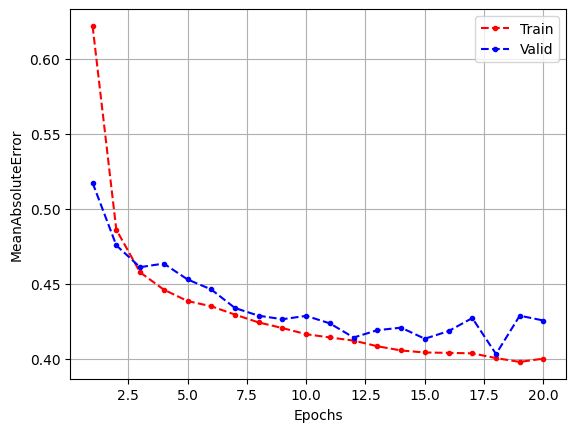

In [ ]:
learning_rate = 0.01
n_epochs=20


# model = nn.Sequential(
# 	nn.Linear(in_features=8, out_features=30), 
# 	nn.Sigmoid(),
# 	nn.Linear(in_features=30, out_features=50), 
# 	nn.Sigmoid(),
# 	nn.Linear(in_features=50, out_features=1)
# ).to(device)
class PriceRegressor(nn.Module):
	def __init__(self, n_features):
		super().__init__()
		self.sequential = nn.Sequential(
			nn.Linear(in_features=n_features, out_features=30), 
			nn.LeakyReLU(),
			nn.Linear(in_features=30, out_features=50), 
			nn.LeakyReLU(),
			nn.Linear(in_features=50, out_features=1)
		)
        
	def forward(self, X):
		y = self.sequential(X)
		return y
model = PriceRegressor(n_features=8).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs)

Epoch: 1/20, Loss: 2.927, Train Metric: 1.285, Valid Metric: 0.679
Epoch: 2/20, Loss: 0.681, Train Metric: 0.613, Valid Metric: 0.586
Epoch: 3/20, Loss: 0.59, Train Metric: 0.567, Valid Metric: 0.56
Epoch: 4/20, Loss: 0.567, Train Metric: 0.549, Valid Metric: 0.554
Epoch: 5/20, Loss: 0.551, Train Metric: 0.541, Valid Metric: 0.54
Epoch: 6/20, Loss: 0.537, Train Metric: 0.532, Valid Metric: 0.531
Epoch: 7/20, Loss: 0.526, Train Metric: 0.524, Valid Metric: 0.521
Epoch: 8/20, Loss: 0.515, Train Metric: 0.518, Valid Metric: 0.517
Epoch: 9/20, Loss: 0.505, Train Metric: 0.513, Valid Metric: 0.513
Epoch: 10/20, Loss: 0.497, Train Metric: 0.508, Valid Metric: 0.506
Epoch: 11/20, Loss: 0.489, Train Metric: 0.503, Valid Metric: 0.508
Epoch: 12/20, Loss: 0.483, Train Metric: 0.5, Valid Metric: 0.499
Epoch: 13/20, Loss: 0.476, Train Metric: 0.495, Valid Metric: 0.499
Epoch: 14/20, Loss: 0.471, Train Metric: 0.493, Valid Metric: 0.493
Epoch: 15/20, Loss: 0.465, Train Metric: 0.49, Valid Metric: 0

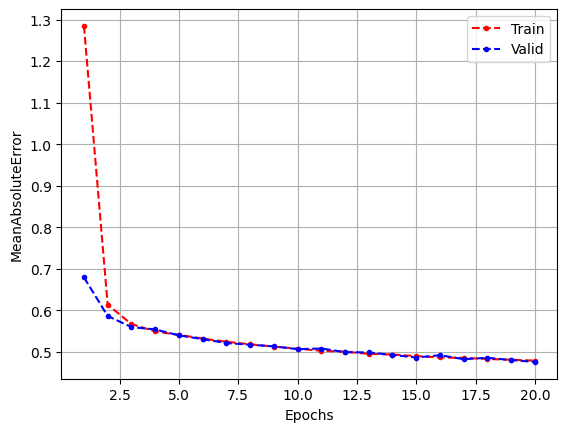

In [ ]:
learning_rate = 0.001
n_epochs=20

class ResidualRegressor(nn.Module):
	def __init__(self, n_features):
		super().__init__()
		self.sequential = nn.Sequential(
			nn.Linear(in_features=n_features, out_features=30), 
			nn.LeakyReLU(),
			nn.Linear(in_features=30, out_features=10), 
			nn.LeakyReLU(),
		)
		self.output_layer = nn.Linear(in_features=10 + n_features, out_features=1)
        
	def forward(self, X):
		y_seqential = self.sequential(X)
		y_combined = torch.concat([X, y_seqential], dim=1)
		y = self.output_layer(y_combined)
		return y
model = ResidualRegressor(n_features=8).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs)

In [11]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

Epoch: 1/20, Loss: 2.49, Train Metric: 1.182, Valid Metric: 0.776
Epoch: 2/20, Loss: 0.812, Train Metric: 0.687, Valid Metric: 0.664
Epoch: 3/20, Loss: 0.651, Train Metric: 0.617, Valid Metric: 0.612
Epoch: 4/20, Loss: 0.599, Train Metric: 0.582, Valid Metric: 0.583
Epoch: 5/20, Loss: 0.572, Train Metric: 0.563, Valid Metric: 0.564
Epoch: 6/20, Loss: 0.554, Train Metric: 0.549, Valid Metric: 0.552
Epoch: 7/20, Loss: 0.539, Train Metric: 0.54, Valid Metric: 0.539
Epoch: 8/20, Loss: 0.525, Train Metric: 0.53, Valid Metric: 0.532
Epoch: 9/20, Loss: 0.512, Train Metric: 0.524, Valid Metric: 0.524
Epoch: 10/20, Loss: 0.501, Train Metric: 0.516, Valid Metric: 0.52
Epoch: 11/20, Loss: 0.491, Train Metric: 0.511, Valid Metric: 0.512
Epoch: 12/20, Loss: 0.482, Train Metric: 0.505, Valid Metric: 0.506
Epoch: 13/20, Loss: 0.473, Train Metric: 0.501, Valid Metric: 0.502
Epoch: 14/20, Loss: 0.466, Train Metric: 0.496, Valid Metric: 0.496
Epoch: 15/20, Loss: 0.46, Train Metric: 0.492, Valid Metric: 

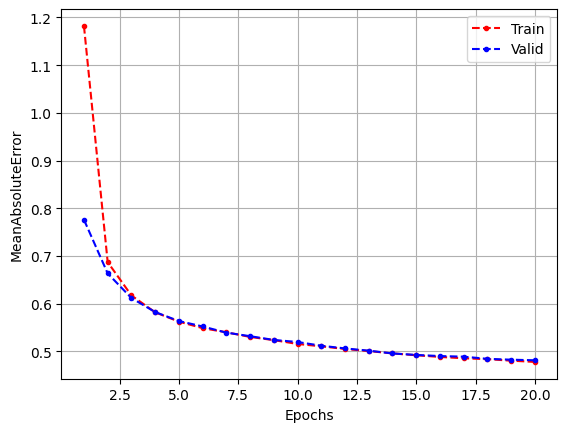

In [20]:
learning_rate = 0.001
n_epochs=20

class GeoVsSocialRegressor(nn.Module):
	def __init__(self, n_features):
		super().__init__()
		self.sequential = nn.Sequential(
			nn.Linear(in_features=n_features-2, out_features=30), 
			nn.LeakyReLU(),
			nn.Linear(in_features=30, out_features=10), 
			nn.LeakyReLU(),
		)
		self.output_layer = nn.Linear(in_features=10 + 2, out_features=1)
        
	def forward(self, X):
		X_geo = X[:, -2:] # 2 cols
		X_soc = X[:, :-2] # 6 cols
		y_soc = self.sequential(X_soc)
		y_combined = torch.concat([X_geo, y_soc], dim=1)
		y = self.output_layer(y_combined)
		return y
model = GeoVsSocialRegressor(n_features=8).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs)

# multiple inputs - single output

Epoch: 1/20, Loss: 3.074, Train Metric: 1.335, Valid Metric: 0.765
Epoch: 2/20, Loss: 0.764, Train Metric: 0.655, Valid Metric: 0.628
Epoch: 3/20, Loss: 0.625, Train Metric: 0.595, Valid Metric: 0.588
Epoch: 4/20, Loss: 0.593, Train Metric: 0.572, Valid Metric: 0.571
Epoch: 5/20, Loss: 0.573, Train Metric: 0.558, Valid Metric: 0.559
Epoch: 6/20, Loss: 0.556, Train Metric: 0.548, Valid Metric: 0.549
Epoch: 7/20, Loss: 0.541, Train Metric: 0.538, Valid Metric: 0.541
Epoch: 8/20, Loss: 0.528, Train Metric: 0.531, Valid Metric: 0.533
Epoch: 9/20, Loss: 0.516, Train Metric: 0.524, Valid Metric: 0.527
Epoch: 10/20, Loss: 0.505, Train Metric: 0.518, Valid Metric: 0.519
Epoch: 11/20, Loss: 0.496, Train Metric: 0.512, Valid Metric: 0.512
Epoch: 12/20, Loss: 0.487, Train Metric: 0.508, Valid Metric: 0.507
Epoch: 13/20, Loss: 0.479, Train Metric: 0.503, Valid Metric: 0.503
Epoch: 14/20, Loss: 0.473, Train Metric: 0.499, Valid Metric: 0.497
Epoch: 15/20, Loss: 0.466, Train Metric: 0.495, Valid Met

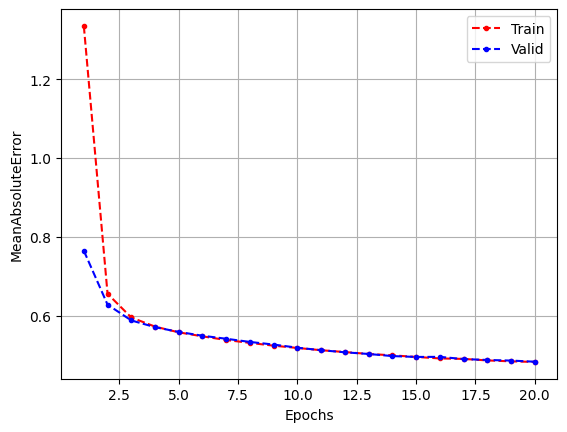

In [ ]:
learning_rate = 0.001
n_epochs=20

class GeoVsSocialRegressorV2(nn.Module):
	def __init__(self, n_features):
		super().__init__()
		self.sequential = nn.Sequential(
			nn.Linear(in_features=n_features-2, out_features=30), 
			nn.LeakyReLU(),
			nn.Linear(in_features=30, out_features=10), 
			nn.LeakyReLU(),
		)
		self.output_layer = nn.Linear(in_features=10 + 2, out_features=1)
        
	def forward(self, X_geo, X_soc):
		y_soc = self.sequential(X_soc)
		y_combined = torch.concat([X_geo, y_soc], dim=1)
		y = self.output_layer(y_combined)
		return y
model = GeoVsSocialRegressorV2(n_features=8).to(device)

train_dataset_geo_soc = TensorDataset(X_train[:, -2:], X_train[:, :-2], y_train) # 2 geo cols, 6 soc cols, labels
valid_dataset_geo_soc = TensorDataset(X_valid[:, -2:], X_valid[:, :-2], y_valid) # 2 geo cols, 6 soc cols, labels
test_dataset_geo_soc = TensorDataset(X_test[:, -2:], X_test[:, :-2], y_test) # 2 geo cols, 6 soc cols, labels

train_loader_geo_soc = DataLoader(train_dataset_geo_soc, batch_size=32, shuffle=True)
valid_loader_geo_soc = DataLoader(valid_dataset_geo_soc, batch_size=32)
test_loader_geo_soc = DataLoader(test_dataset_geo_soc, batch_size=32)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

def train_multi_in_args(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for *X_batch_list, y_batch in train_loader:
			X_batch_list = [X.to(device) for X in X_batch_list]
			model.train()
			y_pred = model(*X_batch_list)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			# for group in optimizer.param_groups:
			# 	for p in group['params']:
			# 		if p.grad is not None:
			# 			print(f'\t{p.grad.max()}') 
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for *X_batch_list, y_batch in valid_loader:
				X_batch_list = [X.to(device) for X in X_batch_list]
				y_pred = model(*X_batch_list)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# if epoch>=2:
		# 	break
	return history

history = train_multi_in_args(model, optimizer, criterion, metric, train_loader_geo_soc, valid_loader_geo_soc, n_epochs)
plot_history(history, n_epochs)

# single input - multiple output

Epoch: 1/20, Loss: 2.758, Train Metric: 1.178, Valid Metric: 0.753
Epoch: 2/20, Loss: 1.032, Train Metric: 0.635, Valid Metric: 0.625
Epoch: 3/20, Loss: 0.692, Train Metric: 0.582, Valid Metric: 0.578
Epoch: 4/20, Loss: 0.602, Train Metric: 0.559, Valid Metric: 0.556
Epoch: 5/20, Loss: 0.573, Train Metric: 0.546, Valid Metric: 0.544
Epoch: 6/20, Loss: 0.559, Train Metric: 0.537, Valid Metric: 0.537
Epoch: 7/20, Loss: 0.549, Train Metric: 0.53, Valid Metric: 0.533
Epoch: 8/20, Loss: 0.54, Train Metric: 0.526, Valid Metric: 0.525
Epoch: 9/20, Loss: 0.532, Train Metric: 0.521, Valid Metric: 0.52
Epoch: 10/20, Loss: 0.525, Train Metric: 0.517, Valid Metric: 0.516
Epoch: 11/20, Loss: 0.518, Train Metric: 0.513, Valid Metric: 0.511
Epoch: 12/20, Loss: 0.511, Train Metric: 0.51, Valid Metric: 0.508
Epoch: 13/20, Loss: 0.505, Train Metric: 0.506, Valid Metric: 0.506
Epoch: 14/20, Loss: 0.5, Train Metric: 0.503, Valid Metric: 0.502
Epoch: 15/20, Loss: 0.495, Train Metric: 0.5, Valid Metric: 0.4

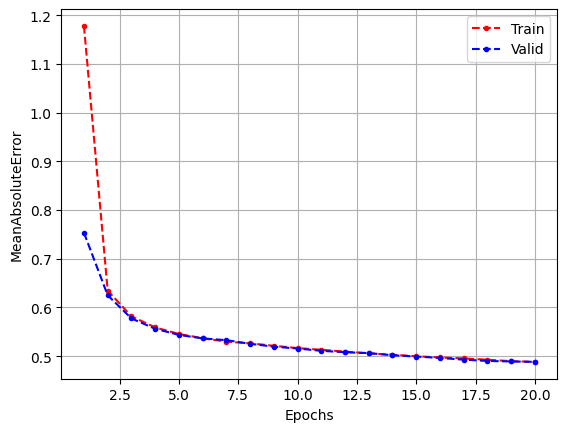

In [27]:
learning_rate = 0.001
n_epochs=20

class GeoVsSocialRegressorMultiOutput(nn.Module):
	def __init__(self, n_features):
		super().__init__()
		self.sequential = nn.Sequential(
			nn.Linear(in_features=n_features-2, out_features=30), 
			nn.LeakyReLU(),
			nn.Linear(in_features=30, out_features=10), 
			nn.LeakyReLU(),
		)
		self.main_output_layer = nn.Linear(in_features=10 + 2, out_features=1)
		self.aux_output_layer = nn.Linear(in_features=10, out_features=1)
        
	def forward(self, X):
		X_geo = X[:, -2:] # 2 cols
		X_soc = X[:, :-2] # 6 cols
		y_seq = self.sequential(X_soc)
		y_combined = torch.concat([X_geo, y_seq], dim=1)
		y_main = self.main_output_layer(y_combined)
		y_aux = self.aux_output_layer(y_seq)
		return y_main, y_aux
model = GeoVsSocialRegressorMultiOutput(n_features=8).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

def train_multi_output(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred_main, y_pred_aux = model(X_batch)
			loss_main = criterion(y_pred_main, y_batch)
			loss_aux = criterion(y_pred_aux, y_batch)
			loss = loss_main * 0.8 + loss_aux * 0.2
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			# for group in optimizer.param_groups:
			# 	for p in group['params']:
			# 		if p.grad is not None:
			# 			print(f'\t{p.grad.max()}') 
			optimizer.zero_grad()
			metric.update(y_pred_main, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred_main, y_pred_aux = model(X_batch)
				metric.update(y_pred_main, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# if epoch>=2:
		# 	break
	return history

history = train_multi_output(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs)